# Eksplorasi Data (surabaya)



In [1]:
import openeo
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Koneksi ke Copernicus Data Space
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

# 2. AOI: Surabaya
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [112.72060203417936, -7.283148232556897],
            [112.72060203417936, -7.3397802255418725],
            [112.78011892090984, -7.3397802255418725],
            [112.78011892090984, -7.283148232556897],
            [112.72060203417936, -7.283148232556897],
        ]
    ],
}

# 3. Ambil data Sentinel-5P (band "NO2")
s5p = connection.load_collection(
    "SENTINEL_5P_L2",
    spatial_extent={
        "west": 112.72060203417936,
        "south": -7.3397802255418725,
        "east": 112.78011892090984,
        "north": -7.283148232556897,
    },
    temporal_extent=["2020-06-01", "2021-06-30"],
    bands=["NO2"],
)

# 4. Mask nilai negatif (data invalid)
def mask_invalid(x):
    return x < 0

s5p_masked = s5p.mask(s5p.apply(mask_invalid))

# 5. Agregasi temporal harian
daily_mean = s5p_masked.aggregate_temporal_period(period="day", reducer="mean")

# 6. Agregasi spasial (rata-rata dalam AOI)
daily_mean_aoi = daily_mean.aggregate_spatial(geometries=aoi, reducer="mean")

# 7. Jalankan batch job dan hasilkan file CSV
job = daily_mean_aoi.execute_batch(out_format="CSV")

# 8. Unduh hasil job
results = job.get_results()
results.download_files("no2_results_surabaya")

# 9. Baca file CSV hasil
for f in os.listdir("no2_results_surabaya"):
    if f.endswith(".csv"):
        df = pd.read_csv(os.path.join("no2_results_surabaya", f))
        print("File ditemukan:", f)
        break

# 10. Pastikan kolom tanggal benar
df["date"] = pd.to_datetime(df["date"])

# 11. Buat kolom bulan (YYYY-MM)
df["month"] = df["date"].dt.to_period("M")

# 12. Hitung rata-rata NO2 per bulan
df_monthly = df.groupby("month", as_index=False)["NO2"].mean()

# 13. Visualisasi hasil
plt.figure(figsize=(10,5))
plt.plot(df_monthly["month"].astype(str), df_monthly["NO2"], marker="o", color="blue", label="NO₂ Rata-rata per Bulan")
plt.title("Rata-rata Bulanan NO₂ (Sentinel-5P) di Surabaya")
plt.xlabel("Bulan")
plt.ylabel("Konsentrasi NO₂")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Authenticated using refresh token.


0:00:00 Job 'j-251101151118403e8054c6ff3b47d4bb': send 'start'


0:00:13 Job 'j-251101151118403e8054c6ff3b47d4bb': created (progress 0%)


0:00:18 Job 'j-251101151118403e8054c6ff3b47d4bb': created (progress 0%)


# Membaca Dataset

In [1]:

import pandas as pd

# 1️⃣ Baca file hasil unduhan dari Copernicus
df = pd.read_csv("no2_results_surabaya/timeseries.csv")

# 2️⃣ Konversi kolom tanggal ke format datetime
df["date"] = pd.to_datetime(df["date"])

# 3️⃣ Urutkan berdasarkan tanggal
df = df.sort_values("date")

# 4️⃣ Tampilkan 5 baris pertama untuk memastikan hasilnya benar
print("Data awal dari Copernicus (5 baris teratas):")
print(df.head())



Data awal dari Copernicus (5 baris teratas):
                         date  feature_index       NO2
122 2020-05-31 00:00:00+00:00              0       NaN
120 2020-06-01 00:00:00+00:00              0       NaN
121 2020-06-02 00:00:00+00:00              0       NaN
282 2020-06-03 00:00:00+00:00              0  0.000016
278 2020-06-04 00:00:00+00:00              0  0.000028


# Jumlah Missing Value

In [15]:
import pandas as pd
import os

# 1️⃣ Baca file hasil dari folder no2_results_surabaya
for f in os.listdir("no2_results_surabaya"):
    if f.endswith(".csv"):
        df = pd.read_csv(os.path.join("no2_results_surabaya", f))
        print("File ditemukan:", f)
        break

# 2️⃣ Pastikan kolom tanggal dalam format datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# 3️⃣ Hitung jumlah & persentase missing value sebelum diperbaiki
missing_before = df["NO2"].isna().sum()
total_rows = len(df)
percent_before = (missing_before / total_rows) * 100
print(f"\nJumlah missing value sebelum diperbaiki: {missing_before} ({percent_before:.2f}%)")

# 4️⃣ Urutkan berdasarkan tanggal dan jadikan index waktu
df = df.sort_values("date")
df = df.set_index("date")

# 5️⃣ Interpolasi berdasarkan waktu dan isi sisa NaN
df["NO2"] = df["NO2"].interpolate(method="time")
df["NO2"] = df["NO2"].fillna(method="ffill").fillna(method="bfill")

# 6️⃣ Hitung ulang jumlah & persentase missing value setelah perbaikan
missing_after = df["NO2"].isna().sum()
percent_after = (missing_after / total_rows) * 100
print(f"Jumlah missing value setelah diperbaiki: {missing_after} ({percent_after:.2f}%)")

# 7️⃣ Kembalikan index ke kolom biasa
df = df.reset_index()

# 8️⃣ Simpan hasil ke file baru
output_file = "no2_surabaya_fixed.csv"
df.to_csv(output_file, index=False)
print(f"\nData hasil perbaikan disimpan ke: {output_file}")

# 9️⃣ Tampilkan sebagian data
print("\nData NO₂ setelah diperbaiki (5 baris teratas):")
print(df.head())


File ditemukan: timeseries.csv

Jumlah missing value sebelum diperbaiki: 184 (46.58%)
Jumlah missing value setelah diperbaiki: 0 (0.00%)

Data hasil perbaikan disimpan ke: no2_surabaya_fixed.csv

Data NO₂ setelah diperbaiki (5 baris teratas):
                       date  feature_index       NO2
0 2020-05-31 00:00:00+00:00              0  0.000016
1 2020-06-01 00:00:00+00:00              0  0.000016
2 2020-06-02 00:00:00+00:00              0  0.000016
3 2020-06-03 00:00:00+00:00              0  0.000016
4 2020-06-04 00:00:00+00:00              0  0.000028


C:\Users\Jordan\AppData\Local\Temp\ipykernel_27392\3473750242.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["NO2"] = df["NO2"].fillna(method="ffill").fillna(method="bfill")


Statistik deskriptif

In [2]:
desc = df.describe()
desc

,feature_index,NO2
count,395.0,211.000000
mean,0.0,0.000034
std,0.0,0.000016
min,0.0,0.000005
25%,0.0,0.000023
50%,0.0,0.000030
75%,0.0,0.000042
max,0.0,0.000096


# Tabel Informasi Dataset

In [3]:
info_table = pd.DataFrame({
    "Kolom": df.columns,
    "Tipe Data": df.dtypes.astype(str),
    "Jumlah Data Tidak Kosong": len(df) - df.isna().sum(),
    "Jumlah Missing": df.isna().sum()
})
info_table

,Kolom,Tipe Data,Jumlah Data Tidak Kosong,Jumlah Missing
date,date,"datetime64[ns, UTC]",395,0
feature_index,feature_index,int64,395,0
NO2,NO2,float64,211,184


# Visualisasi Time Series NO₂

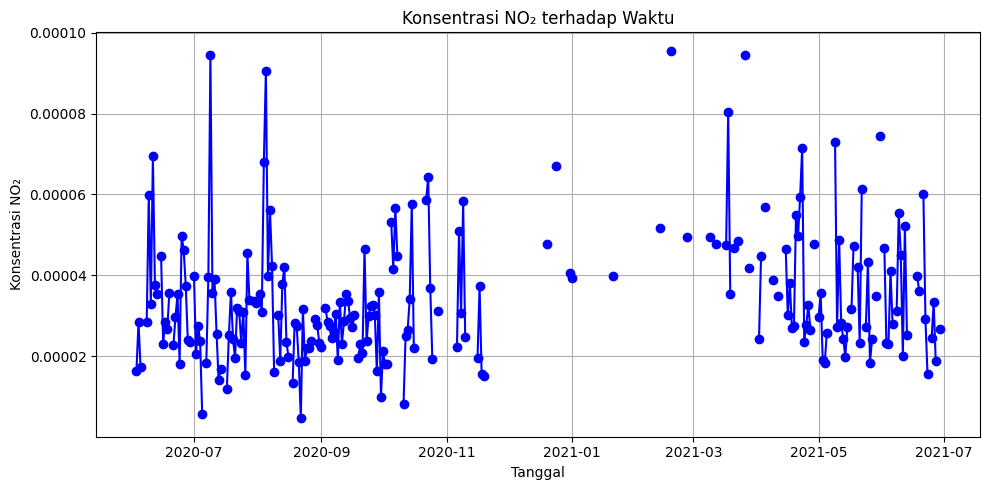

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1️⃣ Baca data hasil Copernicus
df = pd.read_csv("no2_results_surabaya/timeseries.csv")

# 2️⃣ Konversi kolom tanggal ke format datetime
df["date"] = pd.to_datetime(df["date"])

# 3️⃣ Urutkan berdasarkan tanggal
df = df.sort_values("date")

# 4️⃣ Plot hasil
plt.figure(figsize=(10, 5))
plt.plot(df['date'], df['NO2'], marker='o', linestyle='-', color='blue')
plt.title("Konsentrasi NO₂ terhadap Waktu")
plt.xlabel("Tanggal")
plt.ylabel("Konsentrasi NO₂")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:


# 1️⃣ Baca data hasil perbaikan missing value
data = pd.read_csv("no2_surabaya_fixed.csv")

# 2️⃣ Pastikan kolom tanggal berurutan
data["date"] = pd.to_datetime(data["date"])
data = data.sort_values("date").reset_index(drop=True)

# 3️⃣ Tentukan banyaknya lag (misalnya 3 hari sebelumnya)
lag = 3

# 4️⃣ Bentuk fitur lag untuk data supervised
for i in range(1, lag + 1):
    data[f"NO2_t-{i}"] = data["NO2"].shift(i)

# 5️⃣ Hapus baris yang memiliki NaN akibat shift
data_supervised = data.dropna().reset_index(drop=True)

# 6️⃣ Simpan hasilnya ke CSV baru
data_supervised.to_csv("no2_surabaya_supervised.csv", index=False)

# 7️⃣ Tampilkan hasil awal
print("Data supervised (5 baris teratas):")
print(data_supervised.head())


Data supervised (5 baris teratas):
                       date  feature_index       NO2   NO2_t-1   NO2_t-2  \
0 2020-06-03 00:00:00+00:00              0  0.000016  0.000016  0.000016   
1 2020-06-04 00:00:00+00:00              0  0.000028  0.000016  0.000016   
2 2020-06-05 00:00:00+00:00              0  0.000017  0.000028  0.000016   
3 2020-06-06 00:00:00+00:00              0  0.000021  0.000017  0.000028   
4 2020-06-07 00:00:00+00:00              0  0.000025  0.000021  0.000017   

    NO2_t-3  
0  0.000016  
1  0.000016  
2  0.000016  
3  0.000016  
4  0.000028  


In [17]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1️⃣ Baca data supervised hasil langkah sebelumnya
data = pd.read_csv("no2_surabaya_supervised.csv")

# 2️⃣ Pisahkan fitur dan target
X = data[["NO2_t-1", "NO2_t-2", "NO2_t-3"]]
y = data["NO2"]

# 3️⃣ Normalisasi fitur (gunakan StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4️⃣ Bentuk kembali ke DataFrame agar lebih rapi
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# 5️⃣ Gabungkan kembali dengan target
data_normalized = pd.concat([X_scaled_df, y], axis=1)

# 6️⃣ Simpan hasilnya ke CSV
data_normalized.to_csv("no2_surabaya_normalized.csv", index=False)

# 7️⃣ Tampilkan hasil
print("Data setelah normalisasi (5 baris teratas):")
print(data_normalized.head())


Data setelah normalisasi (5 baris teratas):
    NO2_t-1   NO2_t-2   NO2_t-3       NO2
0 -1.332805 -1.330196 -1.329157  0.000016
1 -1.332805 -1.330196 -1.329157  0.000028
2 -0.559284 -1.330196 -1.329157  0.000017
3 -1.268940 -0.557584 -1.329157  0.000021
4 -1.032599 -1.266405 -0.556922  0.000025


In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1️⃣ Baca data hasil normalisasi
data = pd.read_csv("no2_surabaya_normalized.csv")

# 2️⃣ Pisahkan fitur dan target
X = data[["NO2_t-1", "NO2_t-2", "NO2_t-3"]]
y = data["NO2"]

# 3️⃣ Bagi data jadi train & test (misal 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# 4️⃣ Buat model KNN Regressor (contoh: k=3)
knn = KNeighborsRegressor(n_neighbors=3)

# 5️⃣ Latih model
knn.fit(X_train, y_train)

# 6️⃣ Prediksi data test
y_pred = knn.predict(X_test)

# 7️⃣ Evaluasi performa model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# 8️⃣ Tampilkan hasil
print("Hasil Evaluasi Model K-NN Regression")
print("------------------------------------")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"R-squared (R²): {r2:.6f}")
print("\nPerbandingan nilai aktual vs prediksi:")
hasil = pd.DataFrame({"Aktual": y_test.values, "Prediksi": y_pred})
print(hasil.head())


Hasil Evaluasi Model K-NN Regression
------------------------------------
Mean Absolute Error (MAE): 0.000013
R-squared (R²): -0.358745

Perbandingan nilai aktual vs prediksi:
     Aktual  Prediksi
0  0.000038  0.000033
1  0.000041  0.000041
2  0.000044  0.000040
3  0.000046  0.000036
4  0.000030  0.000046


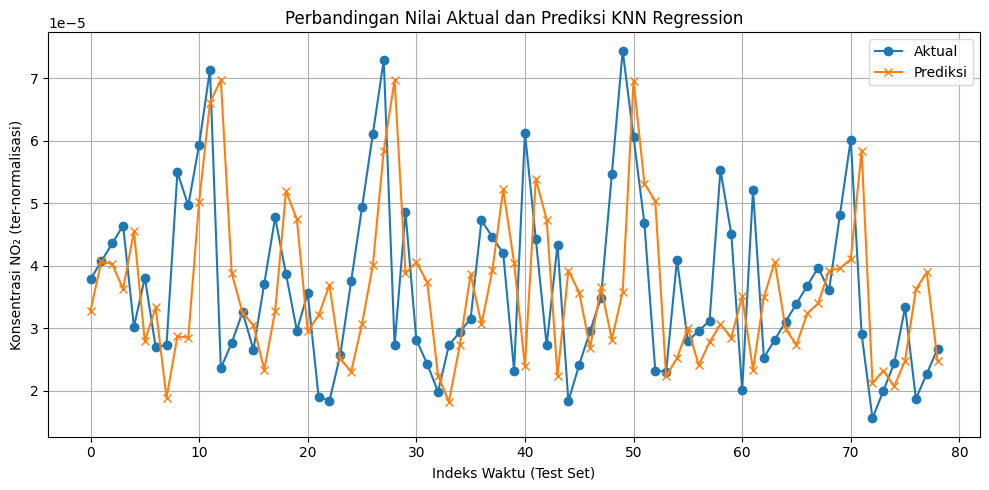

✅ Visualisasi selesai dan hasil disimpan ke 'hasil_prediksi_knn.csv'


In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# Jika belum ada hasilnya, baca ulang data prediksi & aktual
hasil = pd.DataFrame({
    "Aktual": y_test.values,
    "Prediksi": y_pred
}).reset_index(drop=True)

# 1️⃣ Plot hasil prediksi vs aktual
plt.figure(figsize=(10, 5))
plt.plot(hasil["Aktual"], label="Aktual", marker="o")
plt.plot(hasil["Prediksi"], label="Prediksi", marker="x")
plt.title("Perbandingan Nilai Aktual dan Prediksi KNN Regression")
plt.xlabel("Indeks Waktu (Test Set)")
plt.ylabel("Konsentrasi NO₂ (ter-normalisasi)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 2️⃣ (Opsional) Simpan hasil ke file CSV
hasil.to_csv("hasil_prediksi_knn.csv", index=False)
print("✅ Visualisasi selesai dan hasil disimpan ke 'hasil_prediksi_knn.csv'")


Evaluasi Model untuk Berbagai Nilai k:
--------------------------------------
k = 2 --> MAE = 0.000013 | R² = -0.530775
k = 3 --> MAE = 0.000013 | R² = -0.358745
k = 5 --> MAE = 0.000012 | R² = -0.337788
k = 7 --> MAE = 0.000012 | R² = -0.257969
k = 9 --> MAE = 0.000011 | R² = -0.188026
k = 11 --> MAE = 0.000011 | R² = -0.140302


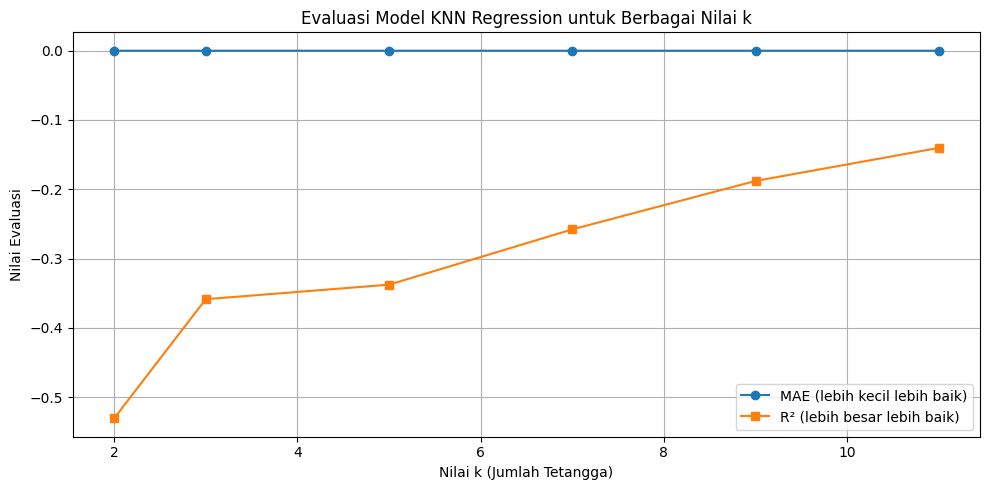

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# 1️⃣ Baca data hasil normalisasi
data = pd.read_csv("no2_surabaya_normalized.csv")

# 2️⃣ Pisahkan fitur & target
X = data[["NO2_t-1", "NO2_t-2", "NO2_t-3"]]
y = data["NO2"]

# 3️⃣ Bagi data jadi train dan test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 4️⃣ Uji beberapa nilai k
k_values = [2, 3, 5, 7, 9, 11]
mae_scores = []
r2_scores = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    mae_scores.append(mae)
    r2_scores.append(r2)

# 5️⃣ Tampilkan hasil evaluasi untuk tiap k
print("Evaluasi Model untuk Berbagai Nilai k:")
print("--------------------------------------")
for i in range(len(k_values)):
    print(f"k = {k_values[i]} --> MAE = {mae_scores[i]:.6f} | R² = {r2_scores[i]:.6f}")

# 6️⃣ Plot hasil evaluasi
plt.figure(figsize=(10,5))
plt.plot(k_values, mae_scores, marker='o', label="MAE (lebih kecil lebih baik)")
plt.plot(k_values, r2_scores, marker='s', label="R² (lebih besar lebih baik)")
plt.title("Evaluasi Model KNN Regression untuk Berbagai Nilai k")
plt.xlabel("Nilai k (Jumlah Tetangga)")
plt.ylabel("Nilai Evaluasi")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [21]:
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor

# 1️⃣ Baca data normalisasi dan model terbaik dari hasil sebelumnya
data = pd.read_csv("no2_surabaya_normalized.csv")

# 2️⃣ Pisahkan fitur dan target
X = data[["NO2_t-1", "NO2_t-2", "NO2_t-3"]]
y = data["NO2"]

# 3️⃣ Gunakan k terbaik (misalnya k=5 dari hasil uji sebelumnya)
model = KNeighborsRegressor(n_neighbors=5)
model.fit(X, y)

# 4️⃣ Siapkan data awal untuk prediksi ke depan
last_values = data[["NO2_t-1", "NO2_t-2", "NO2_t-3"]].iloc[-1].values
forecast_days = 7  # jumlah hari ke depan yang ingin diprediksi
predictions = []

for _ in range(forecast_days):
    # Prediksi nilai berikutnya
    next_pred = model.predict([last_values])[0]
    predictions.append(next_pred)
    
    # Geser nilai lag (misal: t-3 ← t-2, t-2 ← t-1, t-1 ← prediksi)
    last_values = [next_pred, last_values[0], last_values[1]]

# 5️⃣ Simpan hasil prediksi ke DataFrame
forecast_df = pd.DataFrame({
    "Hari_ke": range(1, forecast_days + 1),
    "Prediksi_NO2": predictions
})

# 6️⃣ Tampilkan hasil prediksi
print("📈 Prediksi NO₂ untuk 7 Hari ke Depan:")
print(forecast_df)

# 7️⃣ (Opsional) Simpan ke file CSV
forecast_df.to_csv("no2_surabaya_forecast.csv", index=False)
print("\nHasil prediksi disimpan sebagai 'no2_surabaya_forecast.csv'")


📈 Prediksi NO₂ untuk 7 Hari ke Depan:
   Hari_ke  Prediksi_NO2
0        1      0.000025
1        2      0.000033
2        3      0.000028
3        4      0.000039
4        5      0.000039
5        6      0.000039
6        7      0.000039

Hasil prediksi disimpan sebagai 'no2_surabaya_forecast.csv'


c:\Users\Jordan\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
c:\Users\Jordan\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
c:\Users\Jordan\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
c:\Users\Jordan\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
c:\Users\Jordan\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature nam

In [3]:
import pandas as pd

# 1️⃣ Baca file hasil unduhan dari Copernicus
df = pd.read_csv("no2_results_surabaya/timeseries.csv")

# 2️⃣ Konversi kolom tanggal ke format datetime
df["date"] = pd.to_datetime(df["date"])

# 3️⃣ Urutkan berdasarkan tanggal
df = df.sort_values("date")

# 4️⃣ Tampilkan 5 baris pertama untuk memastikan hasilnya benar
print("Data awal dari Copernicus (5 baris teratas):")
print(df.head())


Data awal dari Copernicus (5 baris teratas):
                         date  feature_index       NO2
122 2020-05-31 00:00:00+00:00              0       NaN
120 2020-06-01 00:00:00+00:00              0       NaN
121 2020-06-02 00:00:00+00:00              0       NaN
282 2020-06-03 00:00:00+00:00              0  0.000016
278 2020-06-04 00:00:00+00:00              0  0.000028
